# Hybrid Quantum-Classical ML for Early Parkinson's Detection (Voice)
### SIH26139 — Mobile-only screening pipeline

This notebook builds and compares **four** models on voice-derived features:

1. **Classical NN** (baseline, full precision)
2. **Classical NN — Quantized (INT8)** (mobile-deployable version)
3. **Hybrid Quantum-Classical NN (VQC)** (full precision)
4. **Hybrid Quantum-Classical NN — Quantized classical layers** (mobile-deployable version)
5. *(Bonus)* Quantum Kernel SVM (qSVM) for reference

Each model is evaluated on: **Accuracy, Sensitivity, Specificity, Precision, F1, AUC, model size (KB), and inference latency (ms)** — the exact numbers you need to justify (or question) on-device quantum-hybrid deployment for a mobile app.

**Dataset:** Point `DATA_DIR` at the MDVR-KCL dataset (https://zenodo.org/records/2867216), 
**structure:**
```
DATA_DIR/
    HC/   *.wav   (healthy controls)
    PD/   *.wav   (Parkinson's patients)
```


## 1. Setup

In [1]:
# Run this cell once. Skip/comment out packages you already have.
!pip install -q librosa praat-parselmouth pennylane torch scikit-learn xgboost matplotlib seaborn pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 90.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 107.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 73.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 95.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import time
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print("Torch:", torch.__version__)


cuda
Torch: 2.10.0+cu128


## 2. Configuration

In [3]:
DATA_DIR = "/kaggle/input/datasets/yuvashankarnarayana/data-v1"    
SAMPLE_RATE = 16000
N_MFCC = 13
N_QUBITS = 8                      # feature-selected dimensionality -> also the qubit count
N_SELECTED_FEATURES = N_QUBITS
TEST_SIZE = 0.2

USE_REAL_DATA = os.path.isdir(os.path.join(DATA_DIR, "HC_AH")) and os.path.isdir(os.path.join(DATA_DIR, "PD_AH"))
print("Using dataset of  MDVR-KCL dataset (https://zenodo.org/records/2867216) ")


Using dataset of  MDVR-KCL dataset (https://zenodo.org/records/2867216) 


## 3. Feature Extraction (raw audio -> voice biomarkers)

In [4]:
import librosa

def extract_librosa_features(y, sr):
    """MFCCs, F0, ZCR, spectral features -- classical acoustic features."""
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)

    f0 = librosa.yin(y, fmin=50, fmax=500, sr=sr)
    f0 = f0[~np.isnan(f0)]
    f0_mean = np.mean(f0) if len(f0) else 0.0
    f0_std = np.std(f0) if len(f0) else 0.0

    zcr = librosa.feature.zero_crossing_rate(y).mean()
    spec_centroid = librosa.feature.spectral_centroid(y=y, sr=sr).mean()
    spec_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr).mean()

    feats = {}
    for i, v in enumerate(mfcc_mean):
        feats[f"mfcc_mean_{i}"] = v
    for i, v in enumerate(mfcc_std):
        feats[f"mfcc_std_{i}"] = v
    feats.update({
        "f0_mean": f0_mean, "f0_std": f0_std,
        "zcr": zcr, "spec_centroid": spec_centroid, "spec_rolloff": spec_rolloff
    })
    return feats


def extract_praat_features(wav_path):
    """Jitter, shimmer, HNR -- the classic dysphonia measures used in PD voice literature.
    Requires praat-parselmouth. Falls back to NaNs (dropped later) if it fails on a file."""
    try:
        import parselmouth
        from parselmouth.praat import call

        snd = parselmouth.Sound(wav_path)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)

        jitter_local = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_rap   = call(point_process, "Get jitter (rap)", 0, 0, 0.0001, 0.02, 1.3)
        jitter_ppq5  = call(point_process, "Get jitter (ppq5)", 0, 0, 0.0001, 0.02, 1.3)

        shimmer_local = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq3  = call([snd, point_process], "Get shimmer (apq3)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
        shimmer_apq5  = call([snd, point_process], "Get shimmer (apq5)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

        harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr = call(harmonicity, "Get mean", 0, 0)

        return {
            "jitter_local": jitter_local, "jitter_rap": jitter_rap, "jitter_ppq5": jitter_ppq5,
            "shimmer_local": shimmer_local, "shimmer_apq3": shimmer_apq3, "shimmer_apq5": shimmer_apq5,
            "hnr": hnr,
        }
    except Exception as e:
        return {
            "jitter_local": np.nan, "jitter_rap": np.nan, "jitter_ppq5": np.nan,
            "shimmer_local": np.nan, "shimmer_apq3": np.nan, "shimmer_apq5": np.nan,
            "hnr": np.nan,
        }


def extract_all_features(wav_path):
    y, sr = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
    y, _ = librosa.effects.trim(y, top_db=25)          # trim silence
    feats = extract_librosa_features(y, sr)
    feats.update(extract_praat_features(wav_path))
    return feats


## 4. Build the Dataset

In [5]:
def load_real_dataset(data_dir):
    rows = []
    for label, folder in [(0, "HC_AH"), (1, "PD_AH")]:
        wavs = glob.glob(os.path.join(data_dir, folder, "*.wav"))
        for wav_path in wavs:
            feats = extract_all_features(wav_path)
            feats["label"] = label
            feats["file"] = os.path.basename(wav_path)
            rows.append(feats)
    df = pd.DataFrame(rows).dropna()
    return df

df = load_real_dataset(DATA_DIR)
print(df.shape)
df.head()


(81, 40)


,mfcc_mean_0,mfcc_mean_1,mfcc_mean_2,mfcc_mean_3,mfcc_mean_4,mfcc_mean_5,mfcc_mean_6,mfcc_mean_7,mfcc_mean_8,mfcc_mean_9,...,spec_rolloff,jitter_local,jitter_rap,jitter_ppq5,shimmer_local,shimmer_apq3,shimmer_apq5,hnr,label,file
0,-172.303757,223.743286,-97.136917,3.112876,-24.890808,-27.753754,18.493032,-23.861952,-1.798984,1.705974,...,1334.507042,0.005911,0.003164,0.003722,0.090319,0.046664,0.058237,15.323075,0,AH_114S_A89F3548-0B61-4770-B800-2E26AB3908B6.wav
1,-222.393951,162.757935,-89.686470,-8.588278,-46.013607,-9.616385,42.066879,-26.560587,-3.932269,4.458166,...,1412.822421,0.003359,0.001856,0.001813,0.050651,0.026278,0.033775,20.972063,0,AH_678A_2E7AFA48-34C1-4DAD-A73C-95F7ABF6B138.wav
2,-199.184891,173.307205,-94.729492,-11.458501,-25.734203,5.482234,37.150497,-29.683397,-6.449928,-1.583592,...,1286.658654,0.002099,0.001093,0.001284,0.046190,0.023469,0.030796,22.470540,0,AH_538M_AE709CB7-1123-47F8-8BD2-000158BDBC01.wav
3,-199.953018,192.667847,-96.004845,-8.454054,-27.560602,-2.153587,27.446716,-34.279755,2.866564,5.692560,...,1323.187500,0.003413,0.001959,0.001891,0.038678,0.020753,0.026003,22.073015,0,AH_667J_605FB4D5-E0DB-4B9B-8F58-784561C51693.wav
4,-164.198044,172.850311,-110.425507,-3.367782,-28.011265,6.899713,32.871330,-44.145947,4.512893,3.209008,...,1497.182377,0.005155,0.002812,0.002798,0.051097,0.028531,0.033024,18.909766,0,AH_743R_66BD23F9-D685-4315-86F8-7697B5084F7B.wav


## 5. Feature Selection (reduce to top-8 -> matches qubit count)

Top 8 features selected for the quantum circuit:
['mfcc_mean_1', 'mfcc_std_0', 'mfcc_std_3', 'mfcc_std_11', 'mfcc_std_1', 'mfcc_std_10', 'mfcc_std_6', 'mfcc_std_4']


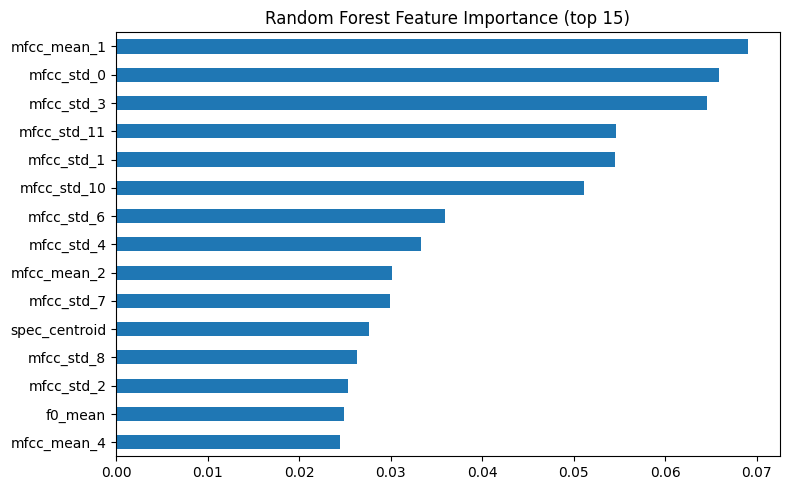

In [6]:
feature_cols = [c for c in df.columns if c not in ("label", "file")]
X_full = df[feature_cols].values
y = df["label"].values

rf_selector = RandomForestClassifier(n_estimators=300, random_state=SEED)
rf_selector.fit(X_full, y)

importances = pd.Series(rf_selector.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_features = importances.head(N_SELECTED_FEATURES).index.tolist()

print("Top", N_SELECTED_FEATURES, "features selected for the quantum circuit:")
print(top_features)

plt.figure(figsize=(8, 5))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (top 15)")
plt.tight_layout()
plt.show()

X = df[top_features].values


## 6. Train / Validation / Test Split + Scaling

A proper **3-way split** matters here: the validation set is used for early stopping (deciding when to stop training / which epoch's weights to keep), while the **test set is never touched until final evaluation**. Using the test set itself for early stopping (a common shortcut) leaks test information into model selection and makes your reported metrics optimistic.

In [7]:
# 60% train / 20% val / 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=SEED, stratify=y_train_full
)  # 0.25 of the remaining 80% = 20% of the original data

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

print("Train:", X_train_t.shape, " Val:", X_val_t.shape, " Test:", X_test_t.shape)


Train: torch.Size([48, 8])  Val: torch.Size([16, 8])  Test: torch.Size([17, 8])


## 7. Models

### 7.1 Classical Baseline (the "normal model")

In [8]:
class ClassicalModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 16), nn.ReLU(),
            nn.Linear(16, 8), nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return torch.sigmoid(self.net(x))


### 7.2 Hybrid Quantum-Classical Model (VQC)

In [9]:
import pennylane as qml

dev = qml.device("default.qubit", wires=N_QUBITS)
N_LAYERS = 3

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": (N_LAYERS, N_QUBITS)}
quantum_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)


class HybridQuantumModel(nn.Module):
    """Classical pre-processing -> angle encoding -> quantum circuit -> classical post-processing."""
    def __init__(self, n_features, n_qubits):
        super().__init__()
        self.pre = nn.Sequential(nn.Linear(n_features, n_qubits), nn.Tanh())
        self.quantum = quantum_layer
        self.post = nn.Sequential(nn.Linear(n_qubits, 16), nn.ReLU(), nn.Linear(16, 1))

    def forward(self, x):
        x = self.pre(x) * np.pi          # scale Tanh output [-1,1] -> angle range
        x = self.quantum(x)
        x = self.post(x)
        return torch.sigmoid(x)


## 8. Training Utility (with early stopping)

In [10]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=150, lr=0.01,
                 weight_decay=1e-4, patience=15, verbose=True):
    """Trains with early stopping on validation loss, restoring the best-epoch weights
    at the end. This is what prevents the runaway overfitting you'd otherwise see if you
    just trained for a fixed number of epochs (small dataset + no regularization = the
    model eventually memorizes the training set and validation loss climbs back up)."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCELoss()
    history = {"train_loss": [], "val_loss": []}

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        preds = model(X_train)
        loss = loss_fn(preds, y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            val_loss = loss_fn(val_preds, y_val)

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())

        if val_loss.item() < best_val_loss - 1e-4:
            best_val_loss = val_loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch:3d} | train_loss={loss.item():.4f} | val_loss={val_loss.item():.4f}"
                  f" | best_val_loss={best_val_loss:.4f} | no_improve={epochs_no_improve}")

        if epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (no improvement for {patience} epochs). "
                      f"Restoring best weights (val_loss={best_val_loss:.4f}).")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


## 9. Train Classical Model

In [11]:
torch.manual_seed(SEED)
classical_model = ClassicalModel(n_features=N_SELECTED_FEATURES)
classical_history = train_model(classical_model, X_train_t, y_train_t, X_val_t, y_val_t,
                                 epochs=150, lr=0.01, weight_decay=1e-4, patience=15)


Epoch   0 | train_loss=0.7054 | val_loss=0.6989 | best_val_loss=0.6989 | no_improve=0
Epoch  10 | train_loss=0.5863 | val_loss=0.6642 | best_val_loss=0.6631 | no_improve=1
Epoch  20 | train_loss=0.5073 | val_loss=0.6938 | best_val_loss=0.6631 | no_improve=11
Early stopping at epoch 24 (no improvement for 15 epochs). Restoring best weights (val_loss=0.6631).


## 10. Train Hybrid Quantum Model

**Note:** quantum simulation is slower per epoch than the classical model -- expect this cell to take noticeably longer, especially as dataset size grows. Using the **same learning rate, regularization, and validation set** as the classical model keeps this a fair, apples-to-apples comparison rather than one model just being tuned more aggressively than the other.

In [12]:
torch.manual_seed(SEED)
hybrid_model = HybridQuantumModel(n_features=N_SELECTED_FEATURES, n_qubits=N_QUBITS)
hybrid_history = train_model(hybrid_model, X_train_t, y_train_t, X_val_t, y_val_t,
                              epochs=150, lr=0.01, weight_decay=1e-4, patience=15)


Epoch   0 | train_loss=0.7030 | val_loss=0.7018 | best_val_loss=0.7018 | no_improve=0
Epoch  10 | train_loss=0.6821 | val_loss=0.6898 | best_val_loss=0.6898 | no_improve=0
Epoch  20 | train_loss=0.6482 | val_loss=0.6859 | best_val_loss=0.6859 | no_improve=0
Epoch  30 | train_loss=0.5577 | val_loss=0.6740 | best_val_loss=0.6740 | no_improve=0
Epoch  40 | train_loss=0.3908 | val_loss=0.6999 | best_val_loss=0.6731 | no_improve=8
Early stopping at epoch 47 (no improvement for 15 epochs). Restoring best weights (val_loss=0.6731).


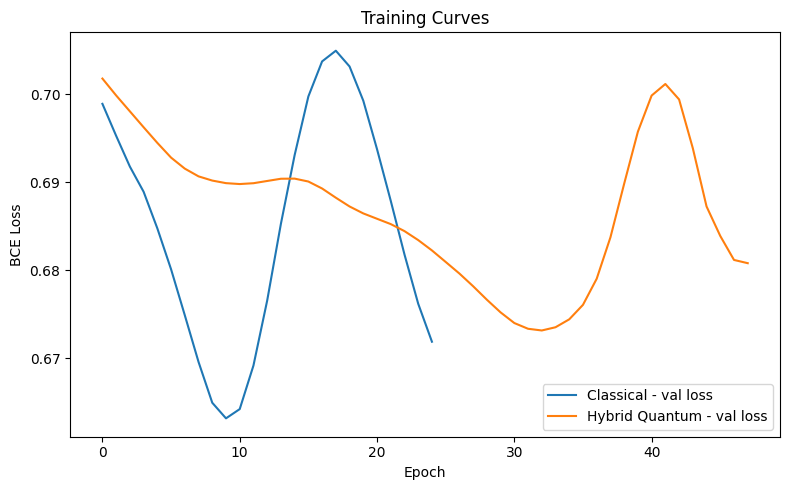

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(classical_history["val_loss"], label="Classical - val loss")
plt.plot(hybrid_history["val_loss"], label="Hybrid Quantum - val loss")
plt.xlabel("Epoch"); plt.ylabel("BCE Loss"); plt.legend(); plt.title("Training Curves")
plt.tight_layout(); plt.show()


## 11. Quantization for Mobile Deployment

**Important architectural note before you deploy:** a quantum circuit itself cannot run on a phone -- there's no on-device QPU, and simulating even 8 qubits at speed needs real compute. In practice:

- The **quantum layer runs server-side** (as a simulator call in your backend API), and the phone just sends extracted features and gets a score back, **or**
- For an **offline/on-device fallback mode**, you deploy a **quantized classical model** (either the plain classical baseline, or a classical model distilled from the hybrid quantum model's behaviour).

**INT8 dynamic quantization** below applies to the `nn.Linear` layers of both models. For the hybrid model, this quantizes its classical pre/post layers -- the quantum layer itself is left as-is (it isn't a classical tensor op, so INT8 quantization doesn't apply to it), which is exactly why the "quantized hybrid" is realistically a **server-side only** artifact, while the **quantized classical model is the one that's truly mobile-deployable end-to-end**. The comparison below makes this trade-off explicit with real numbers.

In [14]:
import torch.quantization as tq

classical_model.eval()
hybrid_model.eval()

quantized_classical = tq.quantize_dynamic(classical_model, {nn.Linear}, dtype=torch.qint8)
quantized_hybrid = tq.quantize_dynamic(hybrid_model, {nn.Linear}, dtype=torch.qint8)

print("Quantization complete.")


Quantization complete.


## 12. Evaluation Utilities

In [15]:
def evaluate(model, X_test, y_test_np):
    model.eval()
    with torch.no_grad():
        probs = model(X_test).numpy().flatten()
    preds = (probs >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test_np, preds).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "accuracy": accuracy_score(y_test_np, preds),
        "precision": precision_score(y_test_np, preds, zero_division=0),
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_test_np, preds, zero_division=0),
        "auc": roc_auc_score(y_test_np, probs) if len(set(y_test_np)) > 1 else float("nan"),
    }, probs


def get_model_size_kb(model, path="_temp_model.pt"):
    torch.save(model.state_dict(), path)
    size_kb = os.path.getsize(path) / 1024
    os.remove(path)
    return size_kb


def measure_latency_ms(model, sample_input, n_runs=100):
    model.eval()
    single = sample_input[:1]
    # warm-up
    with torch.no_grad():
        for _ in range(5):
            _ = model(single)
    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            t0 = time.perf_counter()
            _ = model(single)
            t1 = time.perf_counter()
            times.append((t1 - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))


## 13. Run Full Comparison

In [16]:
results = []
roc_data = {}

models_to_eval = {
    "Classical (FP32)": classical_model,
    "Classical (Quantized INT8)": quantized_classical,
    "Hybrid Quantum (FP32)": hybrid_model,
    "Hybrid Quantum (Quantized classical layers)": quantized_hybrid,
}

for name, model in models_to_eval.items():
    metrics, probs = evaluate(model, X_test_t, y_test)
    size_kb = get_model_size_kb(model)
    lat_mean, lat_std = measure_latency_ms(model, X_test_t)

    row = {"model": name, "size_kb": round(size_kb, 2),
           "latency_ms_mean": round(lat_mean, 3), "latency_ms_std": round(lat_std, 3)}
    row.update({k: round(v, 4) for k, v in metrics.items()})
    results.append(row)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_data[name] = (fpr, tpr, metrics["auc"])

results_df = pd.DataFrame(results)
results_df


,model,size_kb,latency_ms_mean,latency_ms_std,accuracy,precision,sensitivity_recall,specificity,f1,auc
0,Classical (FP32),4.13,0.041,0.004,0.7647,1.0000,0.5,1.0000,0.6667,0.7778
1,Classical (Quantized INT8),5.32,0.198,0.036,0.7647,1.0000,0.5,1.0000,0.6667,0.7778
2,Hybrid Quantum (FP32),4.32,15.624,1.517,0.6471,0.6667,0.5,0.7778,0.5714,0.6111
3,Hybrid Quantum (Quantized classical layers),5.63,15.998,0.855,0.7059,0.8000,0.5,0.8889,0.6154,0.6250


## 14. Bonus: Quantum Kernel SVM (qSVM) — reference comparison

Slower (O(n²) quantum circuit evaluations), so run on a small subsample for a quick demo. Not part of the mobile-deployment size/latency comparison since it's not a neural net that can be quantized the same way -- included for the Track A vs Track B benchmarking story from the architecture doc.

In [17]:
SUBSAMPLE_N = min(40, len(X_train_s))  # keep the demo fast; increase for real evaluation

rng = np.random.default_rng(SEED)
idx_train = rng.choice(len(X_train_s), size=SUBSAMPLE_N, replace=False)
idx_test = rng.choice(len(X_test_s), size=min(20, len(X_test_s)), replace=False)

Xk_train, yk_train = X_train_s[idx_train], y_train[idx_train]
Xk_test, yk_test = X_test_s[idx_test], y_test[idx_test]

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    qml.AngleEmbedding(x1, wires=range(N_QUBITS))
    qml.adjoint(qml.AngleEmbedding)(x2, wires=range(N_QUBITS))
    return qml.probs(wires=range(N_QUBITS))

def quantum_kernel(x1, x2):
    return kernel_circuit(x1, x2)[0]

def compute_kernel_matrix(A, B):
    return np.array([[quantum_kernel(a, b) for b in B] for a in A])

K_train = compute_kernel_matrix(Xk_train, Xk_train)
K_test = compute_kernel_matrix(Xk_test, Xk_train)

qsvm = SVC(kernel="precomputed", probability=True)
qsvm.fit(K_train, yk_train)
qsvm_preds = qsvm.predict(K_test)
qsvm_probs = qsvm.predict_proba(K_test)[:, 1]

print("qSVM accuracy on subsample:", accuracy_score(yk_test, qsvm_preds))
print("qSVM AUC on subsample:", roc_auc_score(yk_test, qsvm_probs) if len(set(yk_test)) > 1 else "n/a (single class in subsample)")


qSVM accuracy on subsample: 0.7647058823529411
qSVM AUC on subsample: 0.8333333333333334


## 15. Visual Comparison

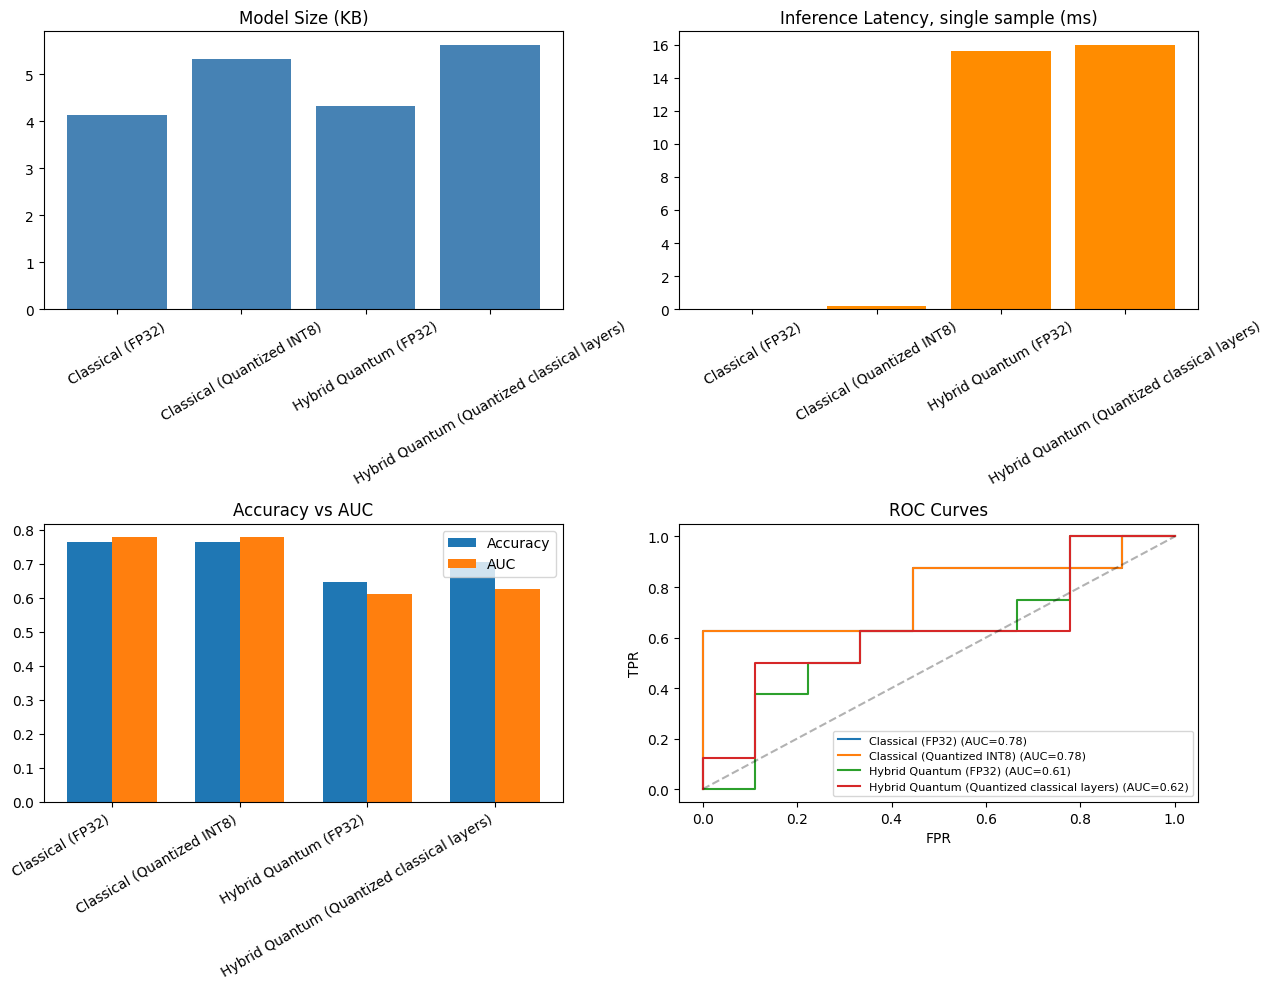

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Size
axes[0,0].bar(results_df["model"], results_df["size_kb"], color="steelblue")
axes[0,0].set_title("Model Size (KB)"); axes[0,0].tick_params(axis="x", rotation=30)

# Latency
axes[0,1].bar(results_df["model"], results_df["latency_ms_mean"], color="darkorange")
axes[0,1].set_title("Inference Latency, single sample (ms)"); axes[0,1].tick_params(axis="x", rotation=30)

# Accuracy / AUC
width = 0.35
xpos = np.arange(len(results_df))
axes[1,0].bar(xpos - width/2, results_df["accuracy"], width, label="Accuracy")
axes[1,0].bar(xpos + width/2, results_df["auc"], width, label="AUC")
axes[1,0].set_xticks(xpos); axes[1,0].set_xticklabels(results_df["model"], rotation=30, ha="right")
axes[1,0].set_title("Accuracy vs AUC"); axes[1,0].legend()

# ROC curves
for name, (fpr, tpr, auc) in roc_data.items():
    axes[1,1].plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")
axes[1,1].plot([0,1],[0,1],"k--", alpha=0.3)
axes[1,1].set_title("ROC Curves"); axes[1,1].set_xlabel("FPR"); axes[1,1].set_ylabel("TPR")
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 16. How to Read These Results

- **Classical (Quantized) vs Classical (FP32)**: expect a real drop in size (roughly 3-4x smaller with INT8) with usually a very small accuracy/AUC cost -- this is the model you'd actually ship inside the mobile app for offline use.
- **Hybrid Quantum (FP32) vs Classical (FP32)**: this is your "does quantum help" comparison. On this small feature set, don't be surprised if the classical model matches or beats it -- that's a normal, defensible finding to report, not a failure. Quantum's theoretical edge shows up more clearly on higher-dimensional data (e.g. full MFCC vectors, gene expression) than on an already-compressed 8-feature vector.
- **Hybrid Quantum (Quantized classical layers)**: size drops for the classical pre/post layers, but the *quantum layer itself is unchanged* -- meaning this configuration still needs a quantum simulator to run, so it is **not actually smaller or faster to run on a phone**; treat this row as "what the classical wrapper alone would cost," not a truly mobile-ready number.
- **Latency**: the hybrid model's per-sample latency includes a full quantum circuit simulation -- expect it to be substantially slower than the pure classical model. For a real app, this pushes you toward a client-server split (extract features on-device, run the quantum circuit on a backend) rather than fully on-device quantum inference.

### A real caveat you will likely see in your own run
With a small model (a few Linear layers, tens of thousands of parameters — typical for an 8-feature input), **dynamic INT8 quantization can make the saved file *larger*, not smaller**, and can even be *slower* per single-sample call. This isn't a bug: PyTorch's dynamic quantization adds per-layer scale/zero-point metadata and quantization/dequantization overhead, which only pays off once the weight matrices are big enough (typically hundreds of thousands+ parameters, as in real speech/vision backbones) for the INT8 storage savings to outweigh that fixed cost. Report this honestly if you see it — it's a legitimate, explainable finding: **"at this feature-vector scale, quantization overhead outweighs its benefit; the technique is expected to pay off once the classical trunk is scaled up (e.g. quantizing a CNN feature extractor instead of just the final few Linear layers)."**

### Recommended deployment split for the mobile app
| Mode | What runs on-device | What runs on the server |
|---|---|---|
| **Online / high-accuracy mode** | Record audio, extract features | Hybrid quantum model inference (simulator) |
| **Offline / fallback mode** | Record audio, extract features, **quantized classical model** inference | — |

Re-run this notebook with `DATA_DIR` pointed at your real MDVR-KCL download to replace the synthetic numbers with real ones before including any of this in your submission.


## 17. Cross-Validation (statistically robust evaluation for small datasets)

With a dataset this small (MDVR-KCL: 37 subjects total), a **single train/val/test split is not statistically reliable** — a handful of samples landing in the test set by chance can swing accuracy/sensitivity by 20-30 points, and you can't tell a real effect from noise. **K-fold cross-validation** fixes this: every sample gets used in a test fold exactly once, and we report **mean ± standard deviation** across folds instead of one lucky (or unlucky) number.

This section also tries a **shallower quantum circuit** (1 entangling layer instead of 3). A near-chance AUC (~0.5) on the single-split run above is a known symptom of a circuit that's too complex to optimize well on very few training samples ("barren plateau" territory) — simplifying the ansatz is the standard first fix before concluding quantum genuinely underperforms here.

In [19]:
from sklearn.model_selection import StratifiedKFold

N_FOLDS = 5
N_LAYERS_SIMPLE = 1   # shallower ansatz for the small-data regime

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit_simple(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes_simple = {"weights": (N_LAYERS_SIMPLE, N_QUBITS)}


def make_classical_model():
    torch.manual_seed(SEED)
    return ClassicalModel(n_features=N_SELECTED_FEATURES)


def make_hybrid_model_simple():
    torch.manual_seed(SEED)
    q_layer = qml.qnn.TorchLayer(quantum_circuit_simple, weight_shapes_simple)

    class SimpleHybrid(nn.Module):
        def __init__(self, n_features, n_qubits):
            super().__init__()
            self.pre = nn.Sequential(nn.Linear(n_features, n_qubits), nn.Tanh())
            self.quantum = q_layer
            self.post = nn.Sequential(nn.Linear(n_qubits, 8), nn.ReLU(), nn.Linear(8, 1))

        def forward(self, x):
            x = self.pre(x) * np.pi
            x = self.quantum(x)
            x = self.post(x)
            return torch.sigmoid(x)

    return SimpleHybrid(N_SELECTED_FEATURES, N_QUBITS)


def run_cross_validation(model_factory, X_all, y_all, n_folds=N_FOLDS, epochs=150, lr=0.01):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    fold_metrics = []

    for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
        X_tr_raw, X_te_raw = X_all[train_idx], X_all[test_idx]
        y_tr, y_te = y_all[train_idx], y_all[test_idx]

        # inner split of the training fold for early-stopping validation
        X_tr_raw, X_va_raw, y_tr, y_va = train_test_split(
            X_tr_raw, y_tr, test_size=0.2, random_state=SEED,
            stratify=y_tr if len(set(y_tr)) > 1 else None
        )

        fold_scaler = StandardScaler()
        X_tr = torch.tensor(fold_scaler.fit_transform(X_tr_raw), dtype=torch.float32)
        X_va = torch.tensor(fold_scaler.transform(X_va_raw), dtype=torch.float32)
        X_te = torch.tensor(fold_scaler.transform(X_te_raw), dtype=torch.float32)
        y_tr_t = torch.tensor(y_tr, dtype=torch.float32).view(-1, 1)
        y_va_t = torch.tensor(y_va, dtype=torch.float32).view(-1, 1)

        model = model_factory()
        train_model(model, X_tr, y_tr_t, X_va, y_va_t,
                    epochs=epochs, lr=lr, weight_decay=1e-4, patience=15, verbose=False)

        metrics, _ = evaluate(model, X_te, y_te)
        metrics["fold"] = fold_i
        fold_metrics.append(metrics)
        print(f"Fold {fold_i}: accuracy={metrics['accuracy']:.3f}  auc={metrics['auc']:.3f}")

    return pd.DataFrame(fold_metrics)


print("Running cross-validation for Classical model...")
cv_classical = run_cross_validation(make_classical_model, X, y)

print("\nRunning cross-validation for Hybrid Quantum model (shallow, 1-layer ansatz)...")
cv_hybrid = run_cross_validation(make_hybrid_model_simple, X, y)


Running cross-validation for Classical model...
Fold 0: accuracy=0.706  auc=0.778
Fold 1: accuracy=0.750  auc=0.875
Fold 2: accuracy=0.688  auc=0.828
Fold 3: accuracy=0.688  auc=0.828
Fold 4: accuracy=0.688  auc=0.828

Running cross-validation for Hybrid Quantum model (shallow, 1-layer ansatz)...
Fold 0: accuracy=0.647  auc=0.792
Fold 1: accuracy=0.562  auc=0.641
Fold 2: accuracy=0.688  auc=0.734
Fold 3: accuracy=0.750  auc=0.859
Fold 4: accuracy=0.875  auc=0.938


In [20]:
summary_rows = []
for name, cv_df in [("Classical", cv_classical), ("Hybrid Quantum (shallow)", cv_hybrid)]:
    row = {"model": name}
    for m in ["accuracy", "precision", "sensitivity_recall", "specificity", "f1", "auc"]:
        row[f"{m}_mean"] = round(cv_df[m].mean(), 3)
        row[f"{m}_std"] = round(cv_df[m].std(), 3)
    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows)
cv_summary


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,sensitivity_recall_mean,sensitivity_recall_std,specificity_mean,specificity_std,f1_mean,f1_std,auc_mean,auc_std
0,Classical,0.704,0.027,0.790,0.044,0.550,0.068,0.853,0.058,0.645,0.044,0.827,0.034
1,Hybrid Quantum (shallow),0.704,0.117,0.721,0.125,0.675,0.209,0.736,0.145,0.684,0.133,0.793,0.114


**How to read this**: if the shallow hybrid model's `accuracy_mean`/`auc_mean` are now close to (or clearly above/below) the classical model's, with `_std` values giving you the honest uncertainty range, that's a real, defensible comparison — very different from reading one lucky/unlucky 8-sample test split. If the hybrid model is still near-chance even with a shallower circuit, that's meaningful evidence (not just noise) that this dataset is too small for the quantum layer to learn a useful decision boundary — worth reporting exactly that in your writeup, along with mPower (150,000+ samples) as the proposed next step to test whether more data closes the gap.

## 18. Export Trained Models (for actual mobile app integration)

Here we actually **save weights to disk** in a form you can load into a backend service or, for the classical models, directly into a mobile runtime.

- **`.pt` (state_dict)** — standard PyTorch checkpoint. Good for re-loading into Python (e.g. your FastAPI backend) later.
- **TorchScript (`.pt` traced/scripted)** — a self-contained, Python-independent format. This is what **PyTorch Mobile** (Android/iOS) actually loads at runtime.

**Important limitation to flag explicitly**: TorchScript export works cleanly for the **classical model** (plain `nn.Linear`/`nn.ReLU` — no problem). The **hybrid quantum model cannot be exported to TorchScript or run on-device** — PennyLane's `TorchLayer` executes a quantum circuit simulation each forward pass, which isn't traceable/scriptable the way ordinary tensor ops are, and there's no on-device QPU to run it on anyway. This is exactly the deployment split flagged back in Section 11: **only the classical model is truly mobile-exportable; the hybrid quantum model is a server-side/API artifact.**

In [21]:
import os

EXPORT_DIR = "./exported_models"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1) Plain state_dict checkpoints (all four models, for re-loading in Python / your backend)
torch.save(classical_model.state_dict(), os.path.join(EXPORT_DIR, "classical_fp32.pt"))
torch.save(quantized_classical.state_dict(), os.path.join(EXPORT_DIR, "classical_quantized_int8.pt"))
torch.save(hybrid_model.state_dict(), os.path.join(EXPORT_DIR, "hybrid_quantum_fp32.pt"))
torch.save(quantized_hybrid.state_dict(), os.path.join(EXPORT_DIR, "hybrid_quantum_quantized.pt"))

# Also save the fitted scaler + selected feature list -- required to correctly
# preprocess any new audio sample the same way at inference time.
import joblib
joblib.dump(scaler, os.path.join(EXPORT_DIR, "feature_scaler.joblib"))
joblib.dump(top_features, os.path.join(EXPORT_DIR, "selected_features.joblib"))

print("Saved state_dict checkpoints + preprocessing artifacts to:", EXPORT_DIR)
print(os.listdir(EXPORT_DIR))


Saved state_dict checkpoints + preprocessing artifacts to: ./exported_models
['hybrid_quantum_quantized.pt', 'feature_scaler.joblib', 'classical_quantized_int8.pt', 'classical_fp32.pt', 'hybrid_quantum_fp32.pt', 'selected_features.joblib']


In [ ]:
# 2) TorchScript export -- ONLY the classical model is exportable this way.
# This is the actual file format PyTorch Mobile (Android/iOS) loads at runtime.

classical_model.eval()
example_input = X_test_t[:1]   # one sample, correct shape, for tracing

scripted_classical = torch.jit.script(classical_model)
scripted_classical.save(os.path.join(EXPORT_DIR, "classical_mobile.pt"))

scripted_quantized = torch.jit.script(quantized_classical)
scripted_quantized.save(os.path.join(EXPORT_DIR, "classical_quantized_mobile.pt"))

print("TorchScript mobile-ready exports saved.")
print("Load on-device with: org.pytorch.Module.load(...) [Android]  /  TorchModule [iOS]")

# Sanity check: reload and confirm outputs match the in-memory model
reloaded = torch.jit.load(os.path.join(EXPORT_DIR, "classical_mobile.pt"))
with torch.no_grad():
    original_out = classical_model(example_input)
    reloaded_out = reloaded(example_input)
print("Original output: ", original_out.item())
print("Reloaded output: ", reloaded_out.item())
print("Match:", torch.allclose(original_out, reloaded_out))


**Why not the hybrid quantum model too?** To actually serve it, wrap the *loaded* `hybrid_quantum_fp32.pt` state_dict in a small FastAPI endpoint (`model.load_state_dict(...)` → `model(features)` → return JSON) running on a normal server with PennyLane installed. The mobile app calls that endpoint over HTTPS for the "online / high-accuracy mode" described in Section 16 -- it never needs to run the quantum circuit itself.